In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('churn_modelling.csv')

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.shape

(10000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [17]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [19]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [21]:
missing_values = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percentage': df.isnull().mean() * 100
})

missing_values

,missing_count,missing_percentage
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


In [23]:
df['CustomerId'].duplicated().sum()

0

In [25]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [27]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [29]:
df['Exited'].unique()

array([1, 0], dtype=int64)

In [31]:
total_customers = df.shape[0]

print('total customers:', total_customers)

total customers: 10000


In [33]:
active_customers = (df['IsActiveMember'] == 1).sum()

print('active customers:', active_customers)

active customers: 5151


In [35]:
exited_customers = (df['Exited'] == 1).sum()

print('exited customers:', exited_customers)

exited customers: 2037


In [37]:
churn_rate = df['Exited'].mean() * 100

print('churn rate:', round(churn_rate, 2), '%')

churn rate: 20.37 %


In [39]:
average_balance = df['Balance'].mean()

print('avg balance:', round(average_balance, 2))

avg balance: 76485.89


In [41]:
average_credit_score = df['CreditScore'].mean()

print('avg credit score:', round(average_credit_score, 2))

avg credit score: 650.53


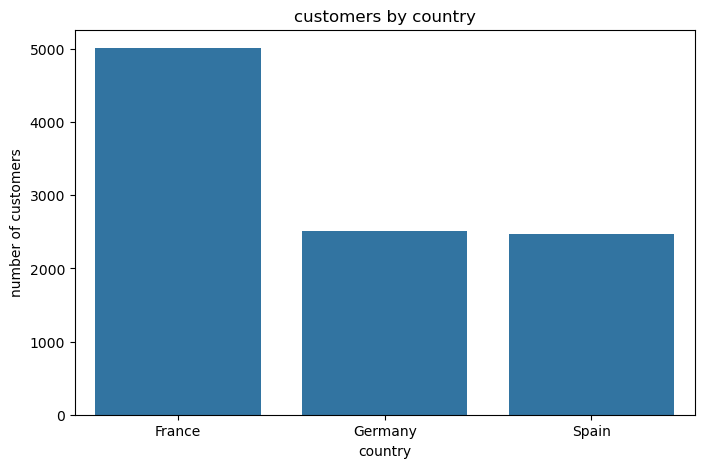

In [43]:
country_customers = df['Geography'].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=country_customers.index,
    y=country_customers.values
)

plt.title('customers by country')
plt.xlabel('country')
plt.ylabel('number of customers')

plt.show()

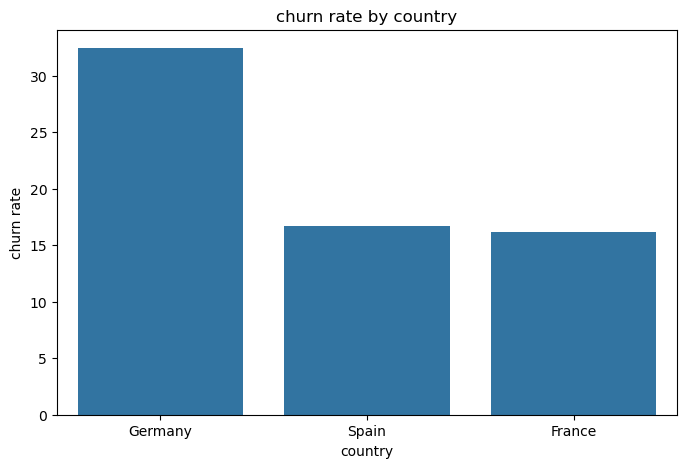

In [44]:
churn_by_country = (
    df.groupby('Geography')['Exited']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=churn_by_country.index,
    y=churn_by_country.values
)

plt.title('churn rate by country')
plt.xlabel('country')
plt.ylabel('churn rate')

plt.show()

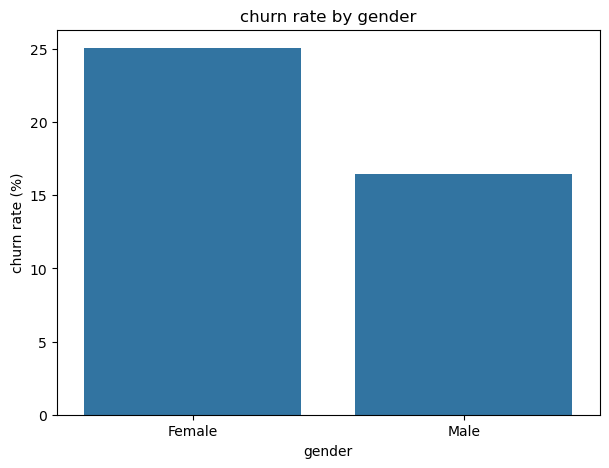

In [46]:
churn_by_gender = (
    df.groupby('Gender')['Exited']
    .mean()
    .mul(100)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=churn_by_gender.index,
    y=churn_by_gender.values
)

plt.title('churn rate by gender')
plt.xlabel('gender')
plt.ylabel('churn rate (%)')

plt.show()

In [49]:
bins = [0, 29, 39, 49, 59, 100]

labels = [
    'under 30',
    '30-39',
    '40-49',
    '50-59',
    '60+'
]

df['age_group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [51]:
df['age_group'].value_counts().sort_index()

age_group
under 30    1641
30-39       4346
40-49       2618
50-59        869
60+          526
Name: count, dtype: int64

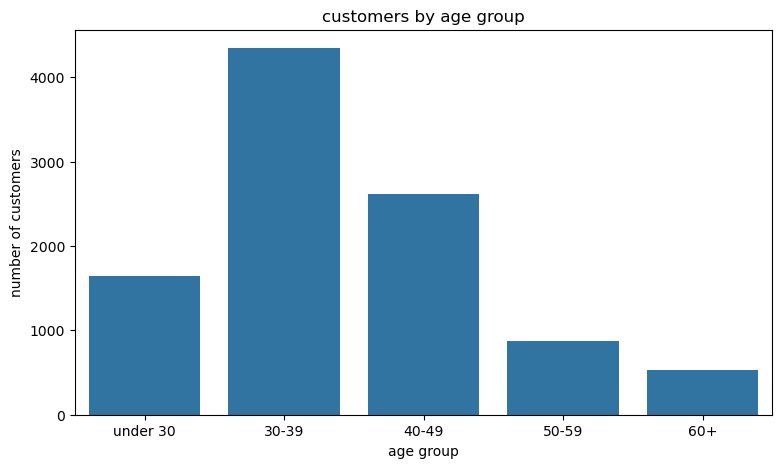

In [53]:
age_group_counts = df['age_group'].value_counts().sort_index()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title('customers by age group')
plt.xlabel('age group')
plt.ylabel('number of customers')

plt.show()

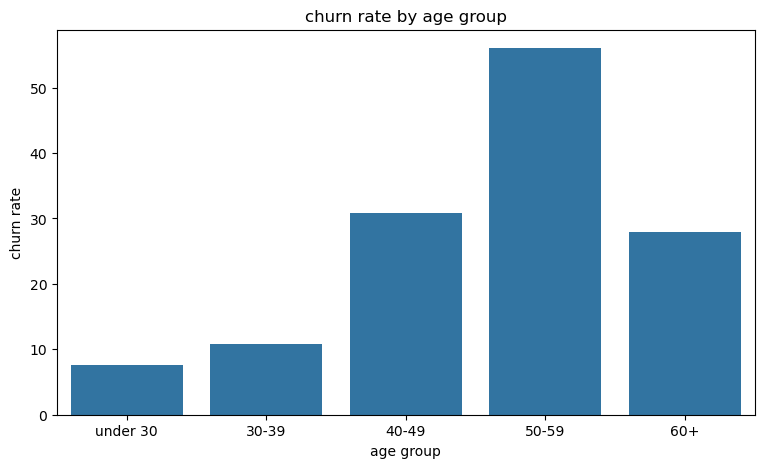

In [55]:
churn_by_age = (
    df.groupby('age_group', observed=True)['Exited']
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=churn_by_age.index,
    y=churn_by_age.values
)

plt.title('churn rate by age group')
plt.xlabel('age group')
plt.ylabel('churn rate')

plt.show()

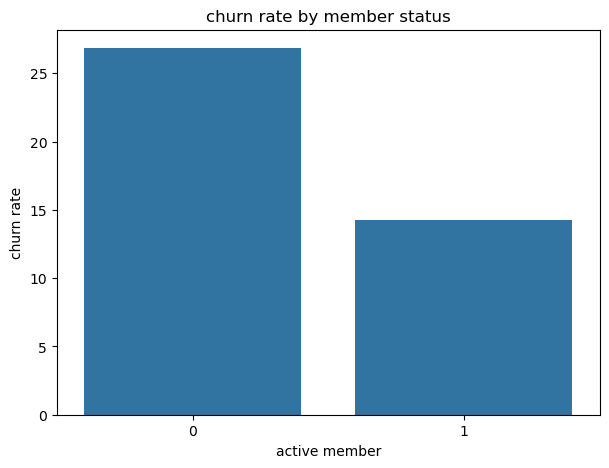

In [57]:
churn_by_activity = (
    df.groupby('IsActiveMember')['Exited']
    .mean()
    .mul(100)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=churn_by_activity.index,
    y=churn_by_activity.values
)

plt.title('churn rate by member status')
plt.xlabel('active member')
plt.ylabel('churn rate')

plt.show()

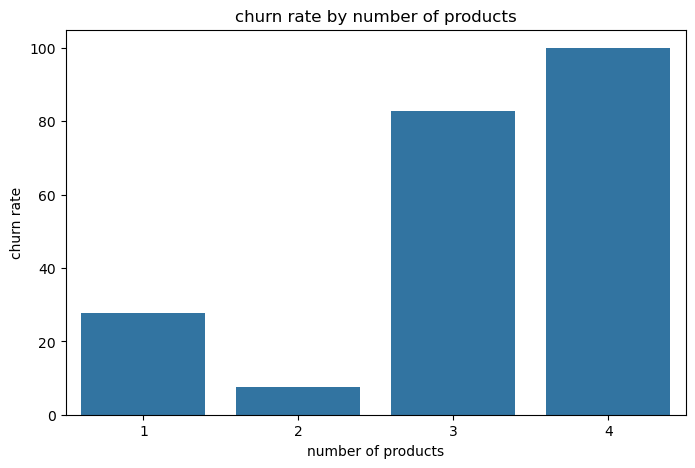

In [58]:
churn_by_products = (
    df.groupby('NumOfProducts')['Exited']
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=churn_by_products.index,
    y=churn_by_products.values
)

plt.title('churn rate by number of products')
plt.xlabel('number of products')
plt.ylabel('churn rate')

plt.show()

In [61]:
df['balance_group'] = pd.cut(
    df['Balance'],
    bins=[-1, 0, 50000, 100000, float('inf')],
    labels=[
        'zero balance',
        'low balance',
        'medium balance',
        'high balance'
    ]
)

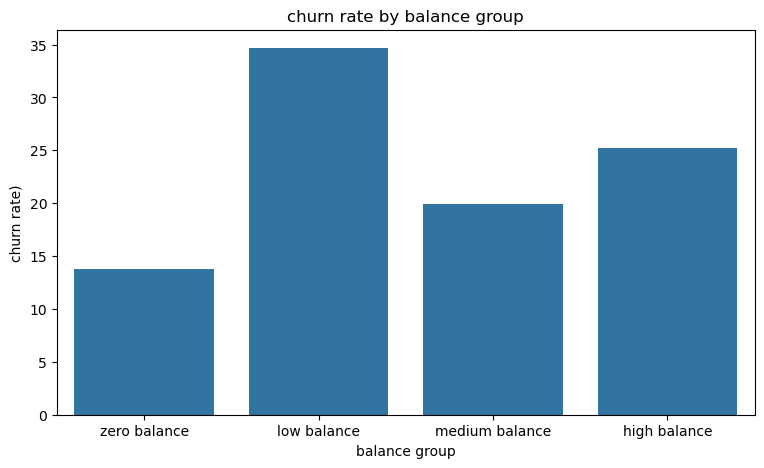

In [63]:
churn_by_balance = (
    df.groupby('balance_group', observed=True)['Exited']
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=churn_by_balance.index,
    y=churn_by_balance.values
)

plt.title('churn rate by balance group')
plt.xlabel('balance group')
plt.ylabel('churn rate)')

plt.show()

In [65]:
df['credit_score_group'] = pd.cut(
    df['CreditScore'],
    bins=[0, 579, 669, 739, 799, 850],
    labels=[
        'poor',
        'fair',
        'good',
        'very good',
        'excellent'
    ]
)

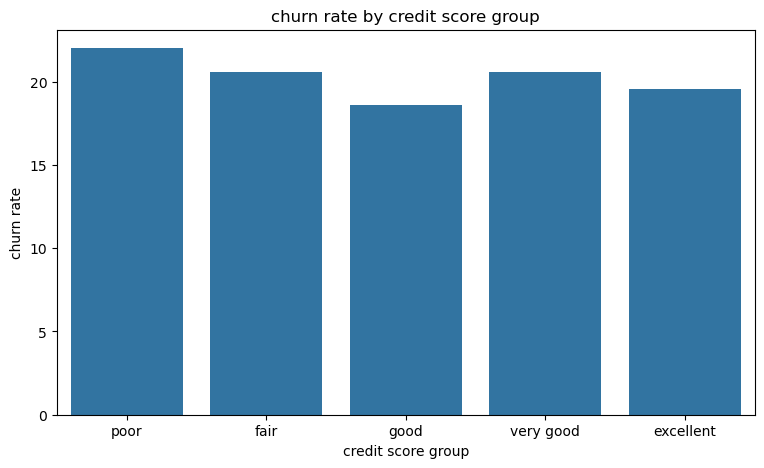

In [67]:
churn_by_credit = (
    df.groupby('credit_score_group', observed=True)['Exited']
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=churn_by_credit.index,
    y=churn_by_credit.values
)

plt.title('churn rate by credit score group')
plt.xlabel('credit score group')
plt.ylabel('churn rate')

plt.show()

In [69]:
tenure_churn = (
    df.groupby('Tenure')['Exited']
    .mean()
    .mul(100)
    .reset_index(name='churn_rate')
)

tenure_churn

,Tenure,churn_rate
0,0,23.002421
1,1,22.415459
2,2,19.179389
3,3,21.110010
4,4,20.525784
5,5,20.652174
6,6,20.268873
7,7,17.217899
8,8,19.219512
9,9,21.646341


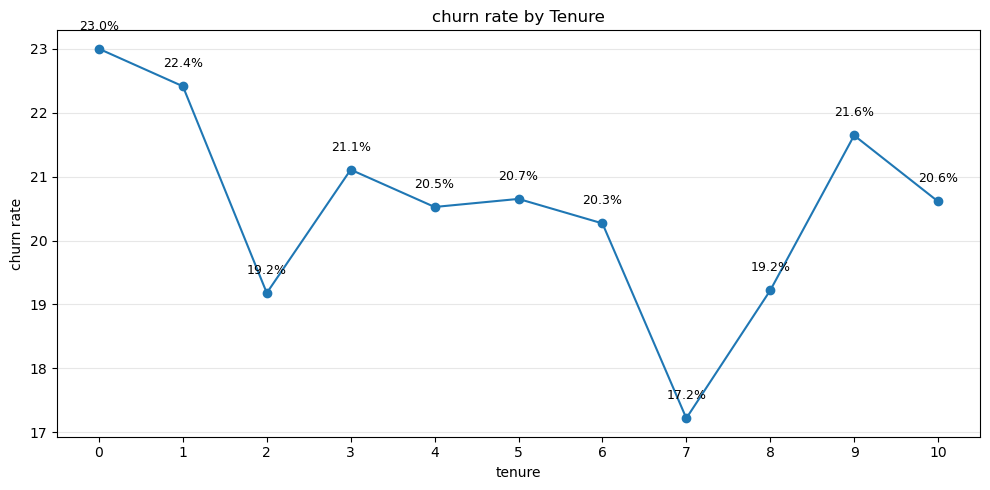

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    tenure_churn['Tenure'],
    tenure_churn['churn_rate'],
    marker='o'
)

plt.title('churn rate by Tenure')
plt.xlabel('tenure')
plt.ylabel('churn rate')

plt.xticks(tenure_churn['Tenure'])
plt.grid(axis='y', alpha=0.3)

for x, y in zip(tenure_churn['Tenure'], tenure_churn['churn_rate']):
    plt.text(
        x,
        y + 0.3,
        f'{y:.1f}%',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### insight

churn rate varies across customer tenure levels, with some tenure groups showing higher churn than others. this indicates that customer retention may change depending on how long customers have been with the bank.

In [82]:
balance_by_country = (
    df.groupby('Geography')['Balance']
    .mean()
    .reset_index(name='average_balance')
    .sort_values('average_balance', ascending=False)
)

balance_by_country

,Geography,average_balance
1,Germany,119730.116134
0,France,62092.636516
2,Spain,61818.147763


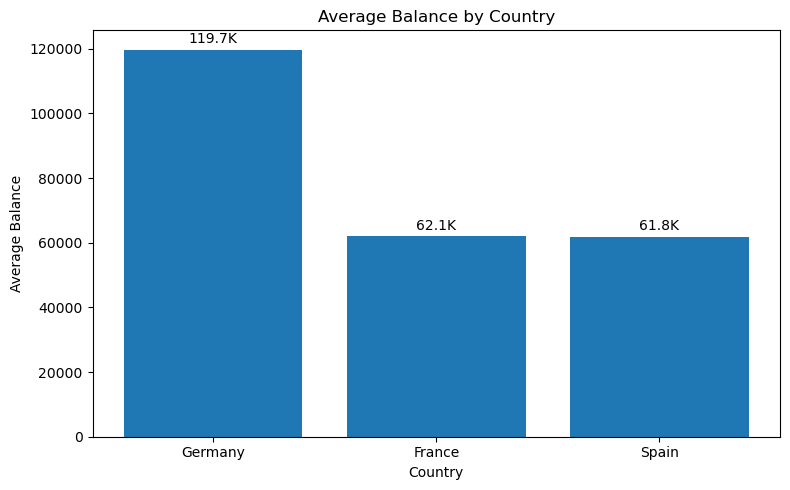

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    balance_by_country['Geography'],
    balance_by_country['average_balance']
)

plt.title('Average Balance by Country')
plt.xlabel('Country')
plt.ylabel('Average Balance')

for x, y in zip(
    balance_by_country['Geography'],
    balance_by_country['average_balance']
):
    plt.text(
        x,
        y + 2000,
        f'{y/1000:.1f}K',
        ha='center'
    )

plt.tight_layout()
plt.show()

In [92]:
salary_by_country = (
    df.groupby('Geography')['EstimatedSalary']
    .mean()
    .reset_index(name='avg_salary')
    .sort_values('avg_salary', ascending=False)
)

salary_by_country

,Geography,avg_salary
1,Germany,101113.435102
0,France,99899.180814
2,Spain,99440.572281


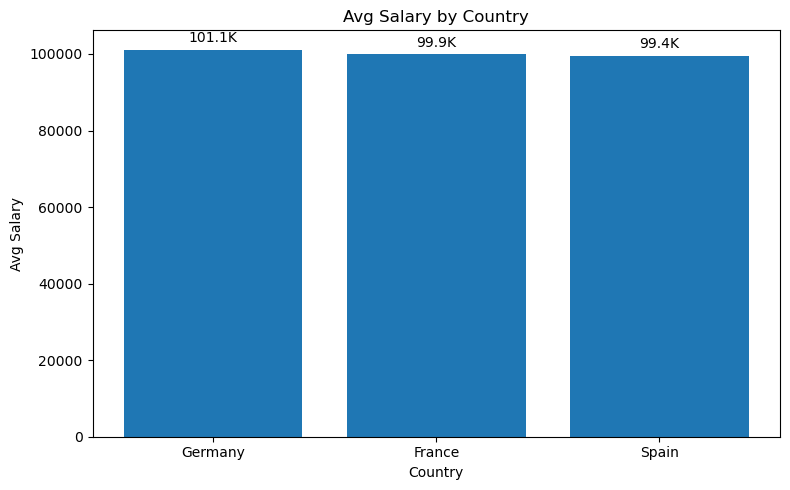

In [96]:
plt.figure(figsize=(8, 5))

plt.bar(
    salary_by_country['Geography'],
    salary_by_country['avg_salary']
)

plt.title('Avg Salary by Country')
plt.xlabel('Country')
plt.ylabel('Avg Salary')

for x, y in zip(
    salary_by_country['Geography'],
    salary_by_country['avg_salary']
):
    plt.text(
        x,
        y + 2000,
        f'{y/1000:.1f}K',
        ha='center'
    )

plt.tight_layout()
plt.show()

### insights

- germany has the highest average customer balance among the three countries.
- average salary is relatively similar across the countries.
- the differences in average balance are more noticeable than the differences in average salary.

In [99]:
age_by_status = (
    df.groupby('Exited')['Age']
    .mean()
    .reset_index(name='avg_age')
)

age_by_status['customer_status'] = age_by_status['Exited'].map({
    0: 'Active',
    1: 'Churned'
})

age_by_status

,Exited,avg_age,customer_status
0,0,37.408389,Active
1,1,44.837997,Churned


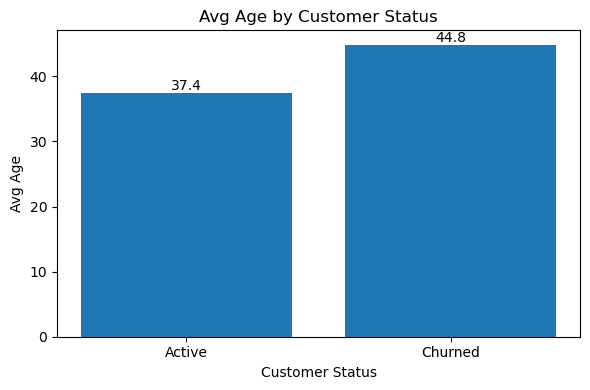

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    age_by_status['customer_status'],
    age_by_status['avg_age']
)

plt.title('Avg Age by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Avg Age')

for x, y in zip(
    age_by_status['customer_status'],
    age_by_status['avg_age']
):
    plt.text(
        x,
        y + 0.5,
        f'{y:.1f}',
        ha='center'
    )

plt.tight_layout()
plt.show()

In [103]:
credit_by_status = (
    df.groupby('Exited')['CreditScore']
    .mean()
    .reset_index(name='avg_credit_score')
)

credit_by_status['customer_status'] = credit_by_status['Exited'].map({
    0: 'Active',
    1: 'Churned'
})

credit_by_status

,Exited,avg_credit_score,customer_status
0,0,651.853196,Active
1,1,645.351497,Churned


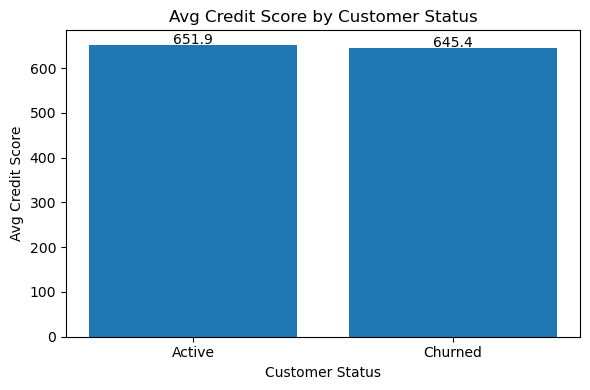

In [105]:
plt.figure(figsize=(6,4))

plt.bar(
    credit_by_status['customer_status'],
    credit_by_status['avg_credit_score']
)

plt.title('Avg Credit Score by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Avg Credit Score')

for x, y in zip(
    credit_by_status['customer_status'],
    credit_by_status['avg_credit_score']
):
    plt.text(
        x,
        y + 2,
        f'{y:.1f}',
        ha='center'
    )

plt.tight_layout()
plt.show()

In [108]:
correlation_data = df[
    [
        'CreditScore',
        'Age',
        'Tenure',
        'Balance',
        'NumOfProducts',
        'EstimatedSalary',
        'Exited'
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204,-0.047820
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,0.012097,1.000000


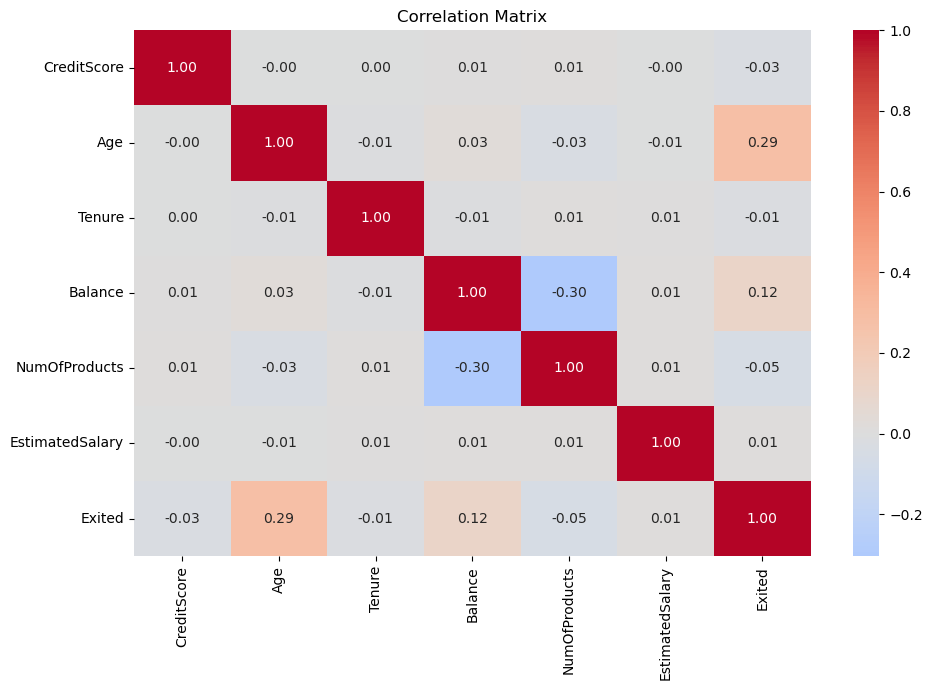

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

## key business insights

### customer churn

- the overall churn rate is approximately 20%.
- a significant proportion of customers have exited the bank.

### geography

- germany has the highest churn rate among the available countries.
- france has a lower churn rate compared with germany.

### age

- churned customers tend to be older than active customers.
- customers in the older age groups show higher churn rates.

### customer activity

- inactive members have a higher churn rate than active members.
- customer activity appears to be an important indicator of churn behavior.

### products

- churn rate varies across the number of products held by customers.
- customers with an unusual number of products should be investigated further.

### financial characteristics

- average customer balance differs across countries.
- average salary is relatively similar across countries.

### credit score

- churned and active customers show differences in their average credit scores.
- credit score groups can help identify customers with different levels of churn risk.

### tenure

- churn rate varies across different tenure levels.
- customer retention behavior is not uniform across the customer lifecycle.

## business recommendations

1. focus retention campaigns on customers with high churn risk.

2. investigate the reasons behind the high churn rate in germany.

3. develop targeted retention strategies for older customers.

4. increase engagement with inactive members through personalized offers and communication.

5. monitor customers based on their number of products and identify unusual product patterns.

6. use credit score, age, geography, balance, activity status, and tenure as indicators when identifying customers at higher churn risk.

7. continuously monitor churn rate across different customer segments to evaluate the effectiveness of retention strategies.